<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/k_means_heart_disease_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("heart.csv")
print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [ ]:
# Example features: Age and Cholesterol
X = data[['age', 'chol']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

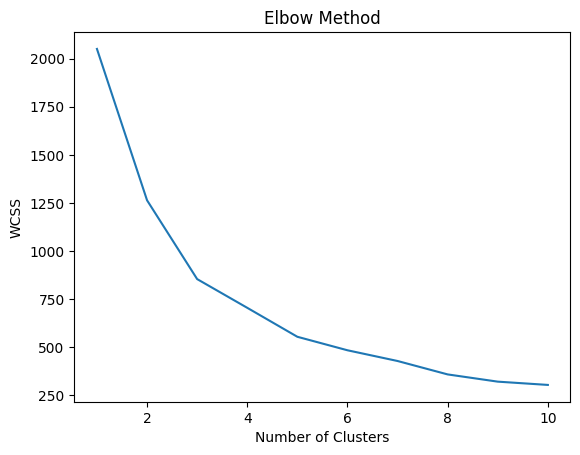

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

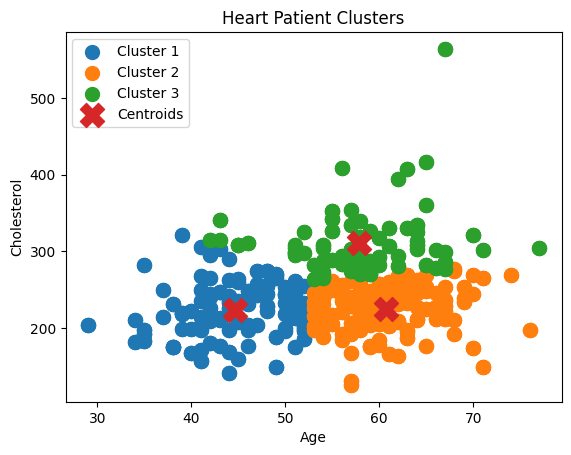

In [ ]:
plt.scatter(X[y_kmeans == 0]['age'],
            X[y_kmeans == 0]['chol'],
            s=100, label='Cluster 1')

plt.scatter(X[y_kmeans == 1]['age'],
            X[y_kmeans == 1]['chol'],
            s=100, label='Cluster 2')

plt.scatter(X[y_kmeans == 2]['age'],
            X[y_kmeans == 2]['chol'],
            s=100, label='Cluster 3')

# Centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centroids[:, 0],
            centroids[:, 1],
            s=300, marker='X', label='Centroids')

plt.title("Heart Patient Clusters")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend()
plt.show()